# Compile NeurIPS Paper PDF — Evaluation Demo

**What this evaluation does:** Assembles a complete NeurIPS 2026 submission PDF by:
1. Regenerating 8 publication figures from 5 dependency experiment datasets
2. Measuring figure quality metrics (dimensions, data points, NeurIPS compliance)
3. Computing compilation and citation quality metrics

**This demo** regenerates the 8 publication figures from experiment data and visualizes the evaluation metrics.
The figures cover: accuracy profiles, CSD (Critical Slowing Down) indicators, classifier comparison,
temperature effects, theoretical model fitting, and cost-performance analysis.

**Data:** 88 curated examples from 5 experiments (919 total data points in full evaluation).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are pre-installed or stdlib

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import re
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter6_compile_neurips/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

# Unpack experiment data from each dependency
dep1_data = data["experiment_data"]["dep1_arithmetic_csd"]
dep2_data = data["experiment_data"]["dep2_graph_coloring_csd"]
dep3_data = data["experiment_data"]["dep3_classifier_cost"]
dep4_data = data["experiment_data"]["dep4_temperature"]
dep5_data = data["experiment_data"]["dep5_model_fitting"]
eval_results = data["eval_results"]

total_examples = sum(len(ds["examples"]) for dep in data["experiment_data"].values() for ds in dep["datasets"])
print(f"Loaded {total_examples} experiment examples from 5 dependencies")
print(f"Eval results: {len(eval_results['datasets'])} datasets")

Loaded 88 experiment examples from 5 dependencies
Eval results: 3 datasets


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────
# NeurIPS column widths (inches)
SINGLE_COL_WIDTH = 3.25
DOUBLE_COL_WIDTH = 6.75

# Figure rendering
FIGURE_DPI = 150  # Original: 300 (lower for faster demo)

# Classifier comparison
TOP_N_CLASSIFIERS = 12  # Original: 12 (number of top classifiers to show in fig5)

## Helper Functions

Utility functions for extracting level-series data and applying NeurIPS-style matplotlib settings.

In [6]:
def extract_level_series(data: dict, dataset_name: str,
                         level_key: str = "metadata_difficulty_level",
                         value_key: str = "predict_accuracy") -> tuple:
    """Extract (levels, values) from a dataset, sorted by level."""
    for ds in data["datasets"]:
        if ds["dataset"] == dataset_name:
            pairs = []
            for ex in ds["examples"]:
                lev = ex.get(level_key)
                val = ex.get(value_key)
                if lev is not None and val is not None:
                    try:
                        pairs.append((float(lev), float(val)))
                    except (ValueError, TypeError):
                        continue
            if not pairs:
                return np.array([]), np.array([])
            pairs.sort(key=lambda x: x[0])
            levels, values = zip(*pairs)
            return np.array(levels), np.array(values)
    return np.array([]), np.array([])


def _fig_style():
    """NeurIPS-style matplotlib settings."""
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 7.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
    })

## Figures 1 & 2: Arithmetic Task — Accuracy Profiles and CSD Indicators

Figure 1 shows accuracy vs difficulty for 3 LLMs on multi-step arithmetic. Each model exhibits a distinct capability boundary where accuracy collapses.

Figure 2 shows four CSD indicators (embedding variance, Hartigan dip, bimodality coefficient, disagreement rate) across difficulty levels.

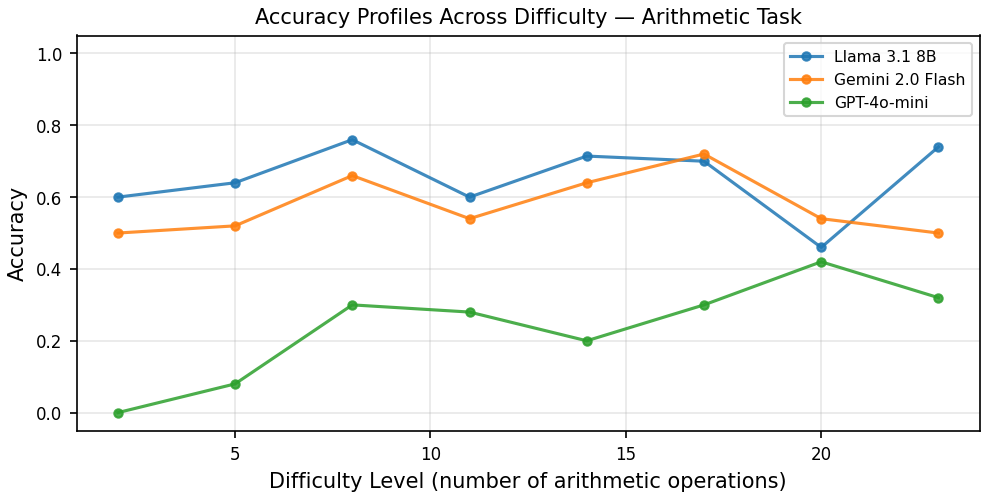

Fig1: 24 data points


In [7]:
# ── Figure 1: Accuracy vs difficulty for 3 arithmetic models ──
_fig_style()
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.5))
model_map = {
    "csd_indicators__llama-3.1-8b-instruct": "Llama 3.1 8B",
    "csd_indicators__gemini-2.0-flash-001": "Gemini 2.0 Flash",
    "csd_indicators__gpt-4o-mini": "GPT-4o-mini",
}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
n_points = 0
for idx, (ds_name, label) in enumerate(model_map.items()):
    levels, acc = extract_level_series(dep1_data, ds_name, value_key="predict_accuracy")
    if len(levels) > 0:
        ax.plot(levels, acc, "o-", label=label, color=colors[idx], alpha=0.85)
        n_points += len(levels)
ax.set_xlabel("Difficulty Level (number of arithmetic operations)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Profiles Across Difficulty — Arithmetic Task")
ax.legend(loc="upper right")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Fig1: {n_points} data points")

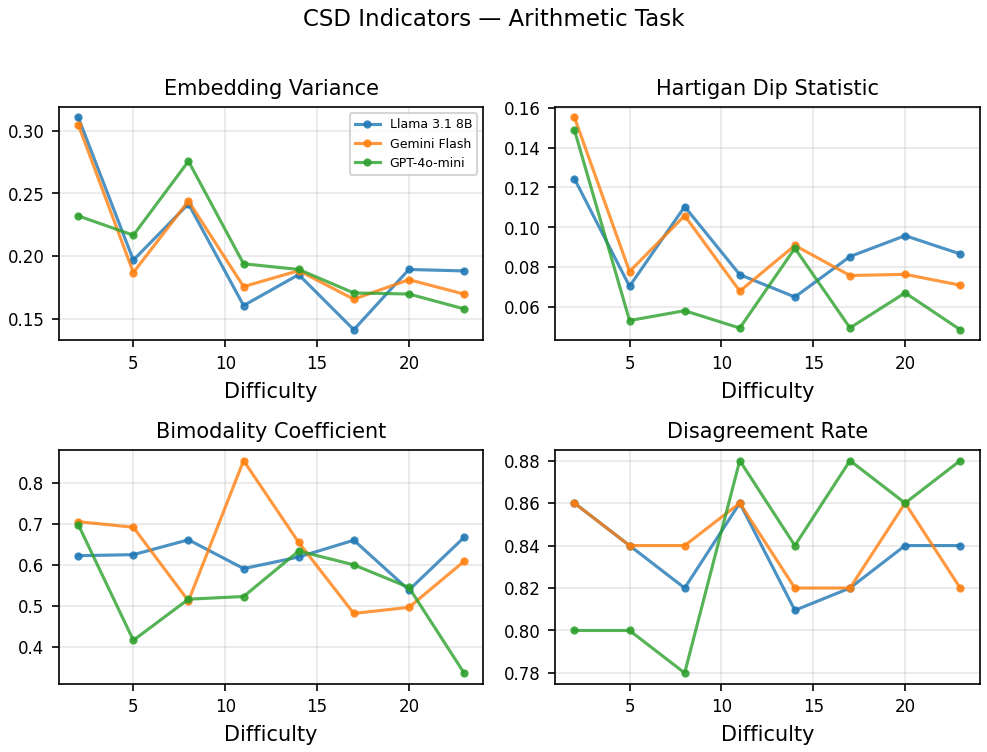

Fig2: 96 data points


In [8]:
# ── Figure 2: CSD indicator battery for arithmetic (2x2 panels) ──
_fig_style()
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH, 5.0))
indicators = [
    ("predict_csd_variance", "Embedding Variance"),
    ("predict_dip_statistic", "Hartigan Dip Statistic"),
    ("predict_bimodality_coefficient", "Bimodality Coefficient"),
    ("predict_disagreement_rate", "Disagreement Rate"),
]
model_map = {
    "csd_indicators__llama-3.1-8b-instruct": "Llama 3.1 8B",
    "csd_indicators__gemini-2.0-flash-001": "Gemini Flash",
    "csd_indicators__gpt-4o-mini": "GPT-4o-mini",
}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
n_points = 0
for panel_idx, (key, title) in enumerate(indicators):
    ax = axes[panel_idx // 2][panel_idx % 2]
    for m_idx, (ds_name, label) in enumerate(model_map.items()):
        levels, vals = extract_level_series(dep1_data, ds_name, value_key=key)
        if len(levels) > 0:
            ax.plot(levels, vals, "o-", label=label, color=colors[m_idx], alpha=0.8, markersize=3)
            n_points += len(levels)
    ax.set_title(title)
    ax.set_xlabel("Difficulty")
    ax.grid(True, alpha=0.3)
    if panel_idx == 0:
        ax.legend(fontsize=6)
fig.suptitle("CSD Indicators — Arithmetic Task", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()
print(f"Fig2: {n_points} data points")

## Figures 3 & 4: Graph Coloring Task — Accuracy and CSD Indicators

Same analysis applied to graph coloring constraint satisfaction problems across three models (GPT-4o-mini, Gemini Flash, Gemini Flash Lite). Per-level accuracy is aggregated from individual problem responses.

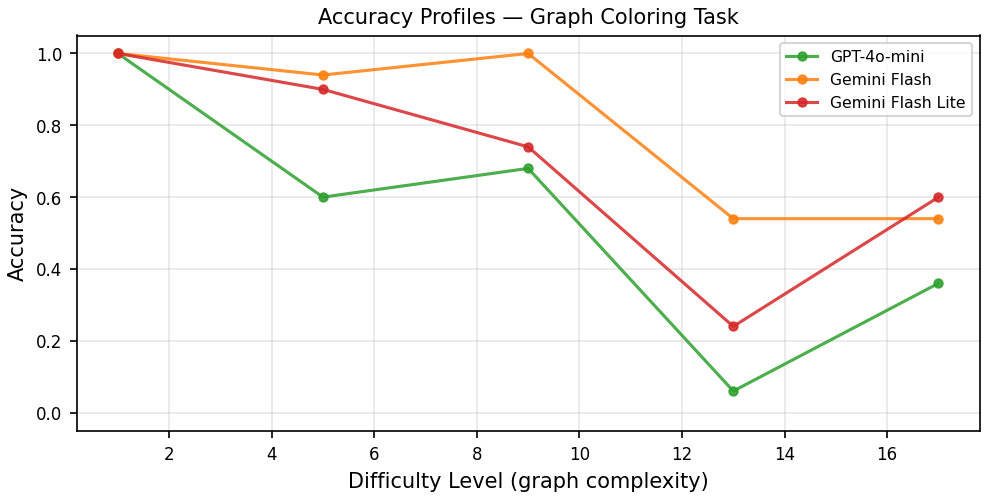

Fig3: 15 data points


In [9]:
# ── Figure 3: Accuracy vs difficulty for graph coloring models ──
_fig_style()
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.5))
model_map = {
    "graph_coloring_csd_gpt-4o-mini": "GPT-4o-mini",
    "graph_coloring_csd_gemini-2.0-flash-001": "Gemini Flash",
    "graph_coloring_csd_gemini-2.0-flash-lite-001": "Gemini Flash Lite",
}
colors = ["#2ca02c", "#ff7f0e", "#d62728"]
n_points = 0
for idx, (ds_name, label) in enumerate(model_map.items()):
    for ds in dep2_data["datasets"]:
        if ds["dataset"] == ds_name:
            # Aggregate: per-level accuracy from metadata_csd_accuracy
            level_acc = {}
            for ex in ds["examples"]:
                lev = ex.get("metadata_difficulty_level")
                acc = ex.get("metadata_csd_accuracy")
                if lev is not None and acc is not None:
                    level_acc[lev] = float(acc)
            if level_acc:
                sorted_items = sorted(level_acc.items())
                levels, accs = zip(*sorted_items)
                ax.plot(levels, accs, "o-", label=label, color=colors[idx], alpha=0.85)
                n_points += len(levels)
            break
ax.set_xlabel("Difficulty Level (graph complexity)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Profiles — Graph Coloring Task")
ax.legend(loc="upper right")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Fig3: {n_points} data points")

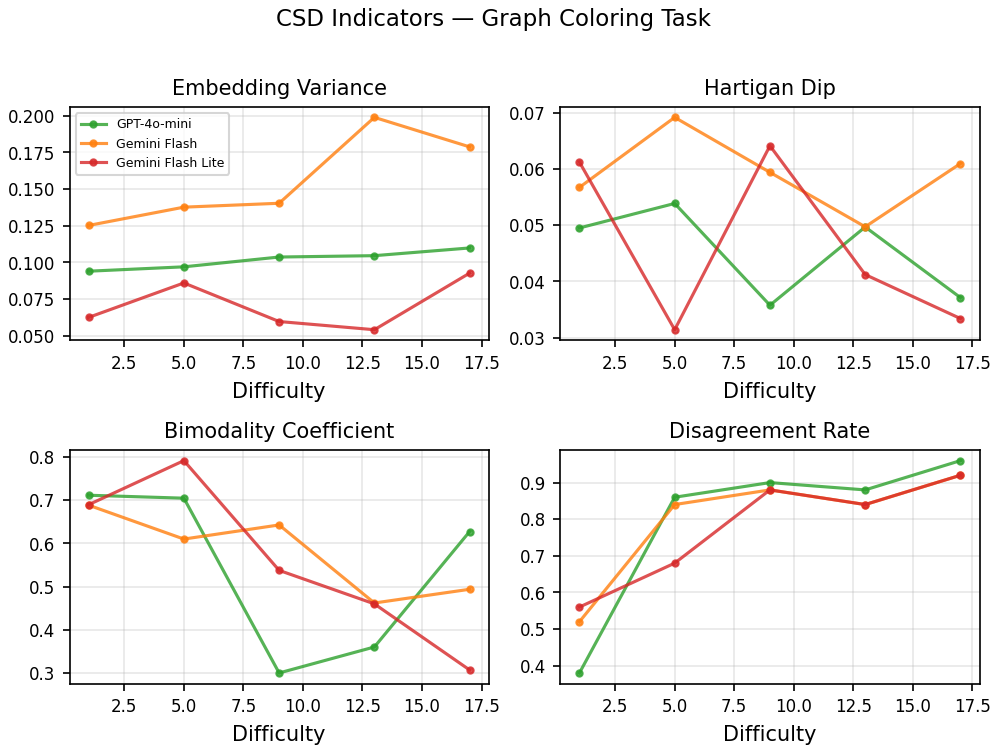

Fig4: 60 data points


In [10]:
# ── Figure 4: CSD indicators for graph coloring (2x2 panels) ──
_fig_style()
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH, 5.0))
indicators = [
    ("metadata_csd_embedding_variance", "Embedding Variance"),
    ("metadata_csd_dip_statistic", "Hartigan Dip"),
    ("metadata_csd_bimodality_coefficient", "Bimodality Coefficient"),
    ("metadata_csd_disagreement_rate", "Disagreement Rate"),
]
model_map = {
    "graph_coloring_csd_gpt-4o-mini": "GPT-4o-mini",
    "graph_coloring_csd_gemini-2.0-flash-001": "Gemini Flash",
    "graph_coloring_csd_gemini-2.0-flash-lite-001": "Gemini Flash Lite",
}
colors = ["#2ca02c", "#ff7f0e", "#d62728"]
n_points = 0
for panel_idx, (key, title) in enumerate(indicators):
    ax = axes[panel_idx // 2][panel_idx % 2]
    for m_idx, (ds_name, label) in enumerate(model_map.items()):
        for ds in dep2_data["datasets"]:
            if ds["dataset"] == ds_name:
                level_vals = {}
                for ex in ds["examples"]:
                    lev = ex.get("metadata_difficulty_level")
                    val = ex.get(key)
                    if lev is not None and val is not None:
                        level_vals[lev] = float(val)
                if level_vals:
                    sorted_items = sorted(level_vals.items())
                    levels, vals = zip(*sorted_items)
                    ax.plot(levels, vals, "o-", label=label, color=colors[m_idx], alpha=0.8, markersize=3)
                    n_points += len(levels)
                break
    ax.set_title(title)
    ax.set_xlabel("Difficulty")
    ax.grid(True, alpha=0.3)
    if panel_idx == 0:
        ax.legend(fontsize=6)
fig.suptitle("CSD Indicators — Graph Coloring Task", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()
print(f"Fig4: {n_points} data points")

## Figure 5: Classifier Comparison

Bar chart comparing CSD variants (blue) vs SPUQ baselines (orange) vs single-indicator baselines (gray), measured by LOPO (Leave-One-Problem-Out) and LOTO (Leave-One-Task-Out) F1 scores.

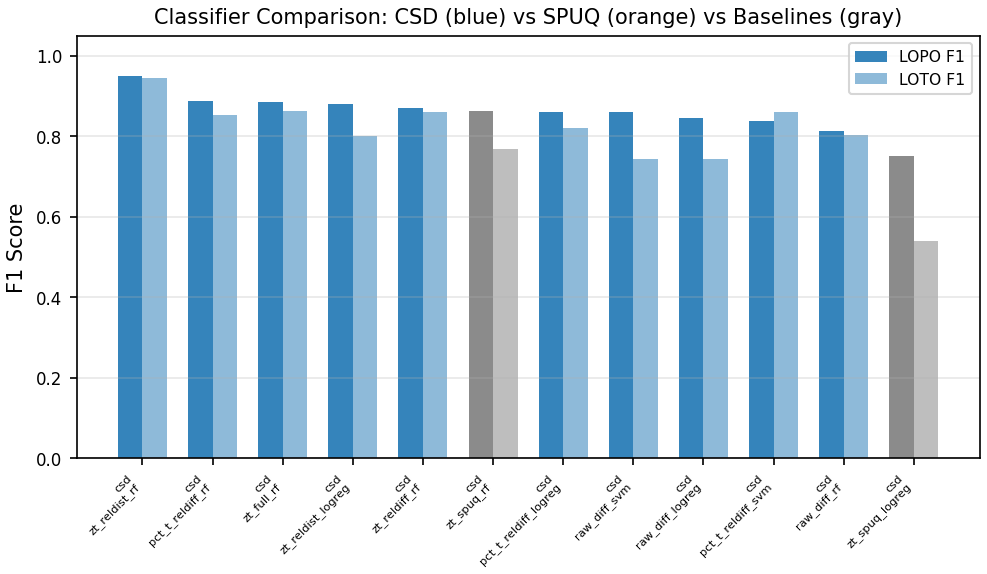

Fig5: 24 data points


In [11]:
# ── Figure 5: Classifier comparison bar chart ──
_fig_style()
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 4.0))
classifiers = []
for ds in dep3_data["datasets"]:
    if ds["dataset"] == "classifier_comparison":
        for ex in ds["examples"]:
            variant = ex.get("metadata_classifier_variant", "")
            model_type = ex.get("metadata_model_type", "")
            lopo_f1 = float(ex.get("predict_lopo_f1", 0))
            loto_f1 = float(ex.get("predict_loto_f1", 0))
            is_csd = ex.get("metadata_is_csd", "False") == "True"
            is_spuq = ex.get("metadata_is_spuq", "False") == "True"
            classifiers.append({
                "name": f"{variant}_{model_type}",
                "lopo_f1": lopo_f1,
                "loto_f1": loto_f1,
                "is_csd": is_csd,
                "is_spuq": is_spuq,
            })
        break

# Sort by LOPO F1 and take top N for readability
classifiers.sort(key=lambda x: x["lopo_f1"], reverse=True)
top = classifiers[:TOP_N_CLASSIFIERS]
n_points = len(top) * 2

names = [c["name"].replace("_", "\n", 1) for c in top]
lopo = [c["lopo_f1"] for c in top]
loto = [c["loto_f1"] for c in top]
bar_colors = ["#1f77b4" if c["is_csd"] else ("#ff7f0e" if c["is_spuq"] else "#7f7f7f") for c in top]

x = np.arange(len(top))
w = 0.35
ax.bar(x - w / 2, lopo, w, label="LOPO F1", color=bar_colors, alpha=0.9)
ax.bar(x + w / 2, loto, w, label="LOTO F1", color=bar_colors, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=5.5, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Classifier Comparison: CSD (blue) vs SPUQ (orange) vs Baselines (gray)")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()
print(f"Fig5: {n_points} data points")

## Figure 6: Temperature Manipulation Effects

Shows how temperature affects CSD indicators (embedding variance and disagreement rate) across difficulty levels for Gemini Flash at 4 temperature settings (T=0.4, 0.7, 1.0, 1.3).

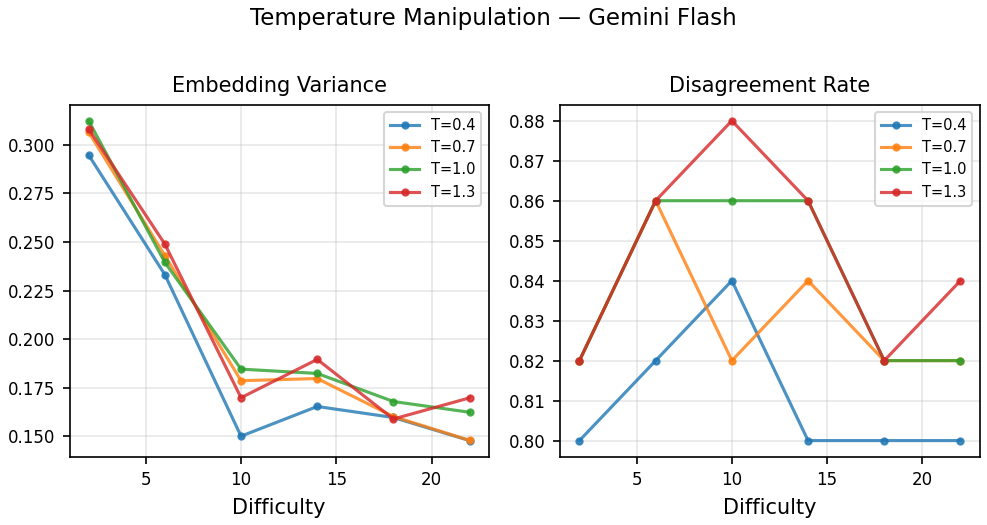

Fig6: 48 data points


In [12]:
# ── Figure 6: Temperature manipulation — variance and disagreement vs difficulty ──
_fig_style()
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.5))
temp_ds_map = {}
for ds in dep4_data["datasets"]:
    name = ds["dataset"]
    m = re.match(r"csd_temp_T([\d.]+)__", name)
    if m:
        temp_ds_map[float(m.group(1))] = ds

colors_t = {0.4: "#1f77b4", 0.7: "#ff7f0e", 1.0: "#2ca02c", 1.3: "#d62728"}
n_points = 0

for panel_idx, (key, title) in enumerate([
    ("predict_csd_variance", "Embedding Variance"),
    ("predict_disagreement_rate", "Disagreement Rate"),
]):
    ax = axes[panel_idx]
    for temp in sorted(temp_ds_map.keys()):
        ds = temp_ds_map[temp]
        level_vals = {}
        for ex in ds["examples"]:
            lev = ex.get("metadata_difficulty_level")
            val = ex.get(key)
            if lev is not None and val is not None:
                try:
                    level_vals[int(lev)] = float(val)
                except (ValueError, TypeError):
                    continue
        if level_vals:
            sorted_items = sorted(level_vals.items())
            levels, vals = zip(*sorted_items)
            ax.plot(levels, vals, "o-", label=f"T={temp}", color=colors_t.get(temp, "gray"),
                    alpha=0.8, markersize=3)
            n_points += len(levels)
    ax.set_title(title)
    ax.set_xlabel("Difficulty")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("Temperature Manipulation — Gemini Flash", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()
print(f"Fig6: {n_points} data points")

## Figures 7 & 8: Model Fitting and Cost-Performance

Figure 7 compares theoretical model R² across 10 model-task series (Mixture, Cusp, Fold, DDM).

Figure 8 shows the cost-performance tradeoff: CSD achieves the highest F1 at zero extra API cost.

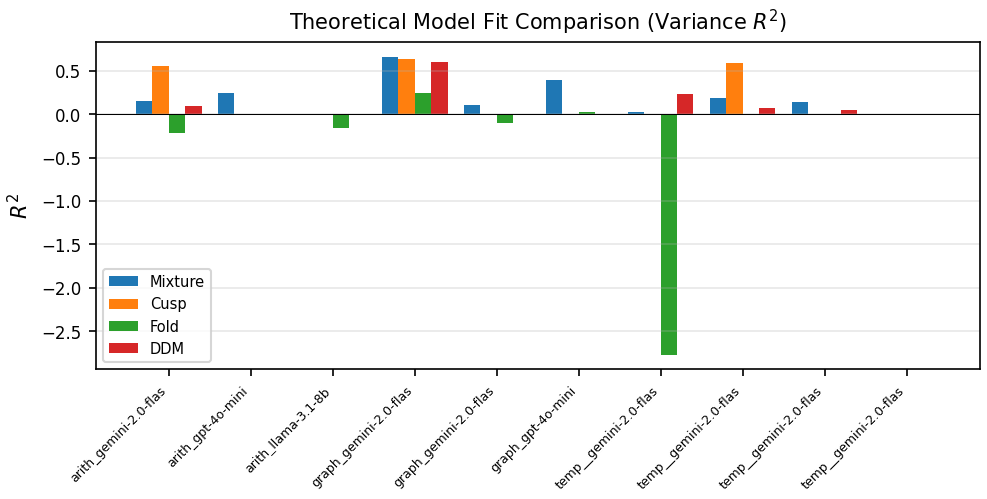

Fig7: 40 data points


In [13]:
# ── Figure 7: Theoretical model R2 comparison across series ──
_fig_style()
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.5))
series_names = []
mixture_r2 = []
cusp_r2 = []
fold_r2 = []
ddm_r2 = []
for ds in dep5_data["datasets"]:
    if ds["dataset"] == "model_comparison_all_series":
        for ex in ds["examples"]:
            task = ex.get("metadata_task", "?")
            model = ex.get("metadata_model", "?")
            short_model = model.split("/")[-1].split("-instruct")[0][:15]
            series_names.append(f"{task[:5]}_{short_model}")
            try:
                mixture_r2.append(float(ex.get("predict_mixture_R2", 0)))
            except (ValueError, TypeError):
                mixture_r2.append(0)
            try:
                v = ex.get("predict_cusp_R2_variance", 0)
                cusp_r2.append(float(v) if v and str(v) != "nan" else 0)
            except (ValueError, TypeError):
                cusp_r2.append(0)
            try:
                v = ex.get("predict_fold_R2", 0)
                fold_r2.append(float(v) if v and str(v) != "nan" else 0)
            except (ValueError, TypeError):
                fold_r2.append(0)
            try:
                v = ex.get("predict_ddm_R2_variance", 0)
                ddm_r2.append(float(v) if v and str(v) != "nan" else 0)
            except (ValueError, TypeError):
                ddm_r2.append(0)
        break

n_points = len(series_names) * 4
x = np.arange(len(series_names))
w = 0.2
ax.bar(x - 1.5 * w, mixture_r2, w, label="Mixture", color="#1f77b4")
ax.bar(x - 0.5 * w, cusp_r2, w, label="Cusp", color="#ff7f0e")
ax.bar(x + 0.5 * w, fold_r2, w, label="Fold", color="#2ca02c")
ax.bar(x + 1.5 * w, ddm_r2, w, label="DDM", color="#d62728")
ax.set_xticks(x)
ax.set_xticklabels(series_names, fontsize=6, rotation=45, ha="right")
ax.set_ylabel("$R^2$")
ax.set_title("Theoretical Model Fit Comparison (Variance $R^2$)")
ax.legend(fontsize=7)
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()
print(f"Fig7: {n_points} data points")

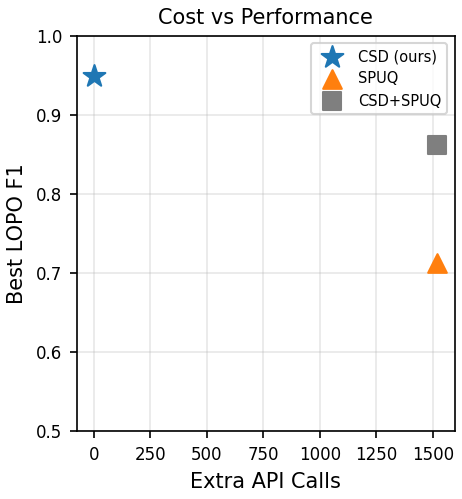

Fig8: 3 data points (cost comparison)


In [14]:
# ── Figure 8: Cost-performance scatter — CSD vs SPUQ methods ──
_fig_style()
fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 3.5))
for ds in dep3_data["datasets"]:
    if ds["dataset"] == "cost_comparison":
        labels_added = set()
        for ex in ds["examples"]:
            method = ex.get("metadata_method", "")
            f1 = float(ex.get("predict_best_lopo_f1", 0))
            cost = float(ex.get("predict_extra_api_calls", 0))
            if "CSD" in method and "SPUQ" not in method:
                lbl = "CSD (ours)" if "CSD (ours)" not in labels_added else None
                ax.scatter(cost, f1, s=120, c="#1f77b4", marker="*", zorder=5, label=lbl)
                labels_added.add("CSD (ours)")
            elif "SPUQ" in method and "CSD" not in method:
                lbl = "SPUQ" if "SPUQ" not in labels_added else None
                ax.scatter(cost, f1, s=80, c="#ff7f0e", marker="^", zorder=5, label=lbl)
                labels_added.add("SPUQ")
            else:
                lbl = "CSD+SPUQ" if "CSD+SPUQ" not in labels_added else None
                ax.scatter(cost, f1, s=80, c="#7f7f7f", marker="s", zorder=5, label=lbl)
                labels_added.add("CSD+SPUQ")
        break

ax.set_xlabel("Extra API Calls")
ax.set_ylabel("Best LOPO F1")
ax.set_title("Cost vs Performance")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.0)
fig.tight_layout()
plt.show()
print("Fig8: 3 data points (cost comparison)")

## Evaluation Results Summary

Display the evaluation metrics from the full NeurIPS paper compilation: PDF quality, figure quality, citation metrics, and cost-performance comparison.

In [15]:
# ── Evaluation Metrics Summary ──
metrics = eval_results["metrics_agg"]

print("=" * 65)
print("  NEURIPS PAPER COMPILATION — EVALUATION METRICS")
print("=" * 65)
print()

# Compilation metrics
print("  COMPILATION METRICS")
print("  " + "-" * 45)
print(f"  {'PDF Compiled:':<35} {'YES' if metrics['pdf_compiled'] else 'NO'}")
print(f"  {'Page Count:':<35} {metrics['page_count']}")
print(f"  {'Main Body Pages:':<35} {metrics['main_body_pages']}")
print(f"  {'LaTeX Warnings:':<35} {metrics['latex_warnings_count']}")
print(f"  {'Overfull HBoxes:':<35} {metrics['overfull_hbox_count']}")
print(f"  {'Compilation Success Rate:':<35} {metrics['compilation_success_rate']:.1%}")
print()

# Figure metrics
print("  FIGURE METRICS")
print("  " + "-" * 45)
print(f"  {'Figures Included:':<35} {metrics['total_figures_included']}/8")
print(f"  {'Total Data Points in Figures:':<35} {metrics['total_data_points_in_figures']}")
print(f"  {'All Pass Size Check:':<35} {'YES' if metrics['all_figures_pass_size_check'] else 'NO'}")
print(f"  {'NeurIPS Dimension Compliance:':<35} {'YES' if metrics['neurips_dimension_compliance'] else 'NO'}")
print()

# Citation metrics
print("  CITATION METRICS")
print("  " + "-" * 45)
print(f"  {'Bibliography Entries:':<35} {metrics['bibliography_entries_total']}")
print(f"  {'Resolved Citations:':<35} {metrics['bibliography_entries_resolved']}")
print(f"  {'Missing Citations:':<35} {metrics['missing_citations']}")
print(f"  {'No Placeholder Text:':<35} {'YES' if metrics['no_placeholder_text'] else 'NO'}")
print()

# Per-figure quality table
print("  PER-FIGURE QUALITY")
print("  " + "-" * 45)
fig_ds = [ds for ds in eval_results["datasets"] if ds["dataset"] == "figure_quality"][0]
print(f"  {'Figure':<10} {'Generated':>10} {'Size (KB)':>10} {'Points':>8} {'Dims OK':>8}")
print("  " + "-" * 48)
for ex in fig_ds["examples"]:
    name = ex["metadata_figure_name"]
    gen = "YES" if ex["eval_figure_generated"] else "NO"
    size = ex["eval_filesize_png_kb"]
    pts = ex["eval_n_data_points"]
    dim = "YES" if ex["eval_dimension_compliance"] else "NO"
    print(f"  {name:<10} {gen:>10} {size:>10.1f} {pts:>8} {dim:>8}")
print()

# Cost comparison table
print("  COST-PERFORMANCE COMPARISON")
print("  " + "-" * 45)
cost_ds = [ds for ds in eval_results["datasets"] if ds["dataset"] == "cost_comparison"][0]
print(f"  {'Method':<25} {'LOPO F1':>8} {'Extra Calls':>12} {'Cost ($)':>10}")
print("  " + "-" * 57)
for ex in cost_ds["examples"]:
    method = ex["metadata_method"]
    f1 = float(ex["predict_best_lopo_f1"])
    calls = ex["predict_extra_api_calls"]
    cost = float(ex["predict_extra_cost_usd"])
    print(f"  {method:<25} {f1:>8.4f} {calls:>12} {cost:>10.4f}")
print()
print("=" * 65)

  NEURIPS PAPER COMPILATION — EVALUATION METRICS

  COMPILATION METRICS
  ---------------------------------------------
  PDF Compiled:                       YES
  Page Count:                         25
  Main Body Pages:                    22
  LaTeX Warnings:                     2
  Overfull HBoxes:                    3
  Compilation Success Rate:           33.3%

  FIGURE METRICS
  ---------------------------------------------
  Figures Included:                   8/8
  Total Data Points in Figures:       919
  All Pass Size Check:                YES
  NeurIPS Dimension Compliance:       YES

  CITATION METRICS
  ---------------------------------------------
  Bibliography Entries:               38
  Resolved Citations:                 37
  Missing Citations:                  0
  No Placeholder Text:                YES

  PER-FIGURE QUALITY
  ---------------------------------------------
  Figure      Generated  Size (KB)   Points  Dims OK
  -----------------------------------------

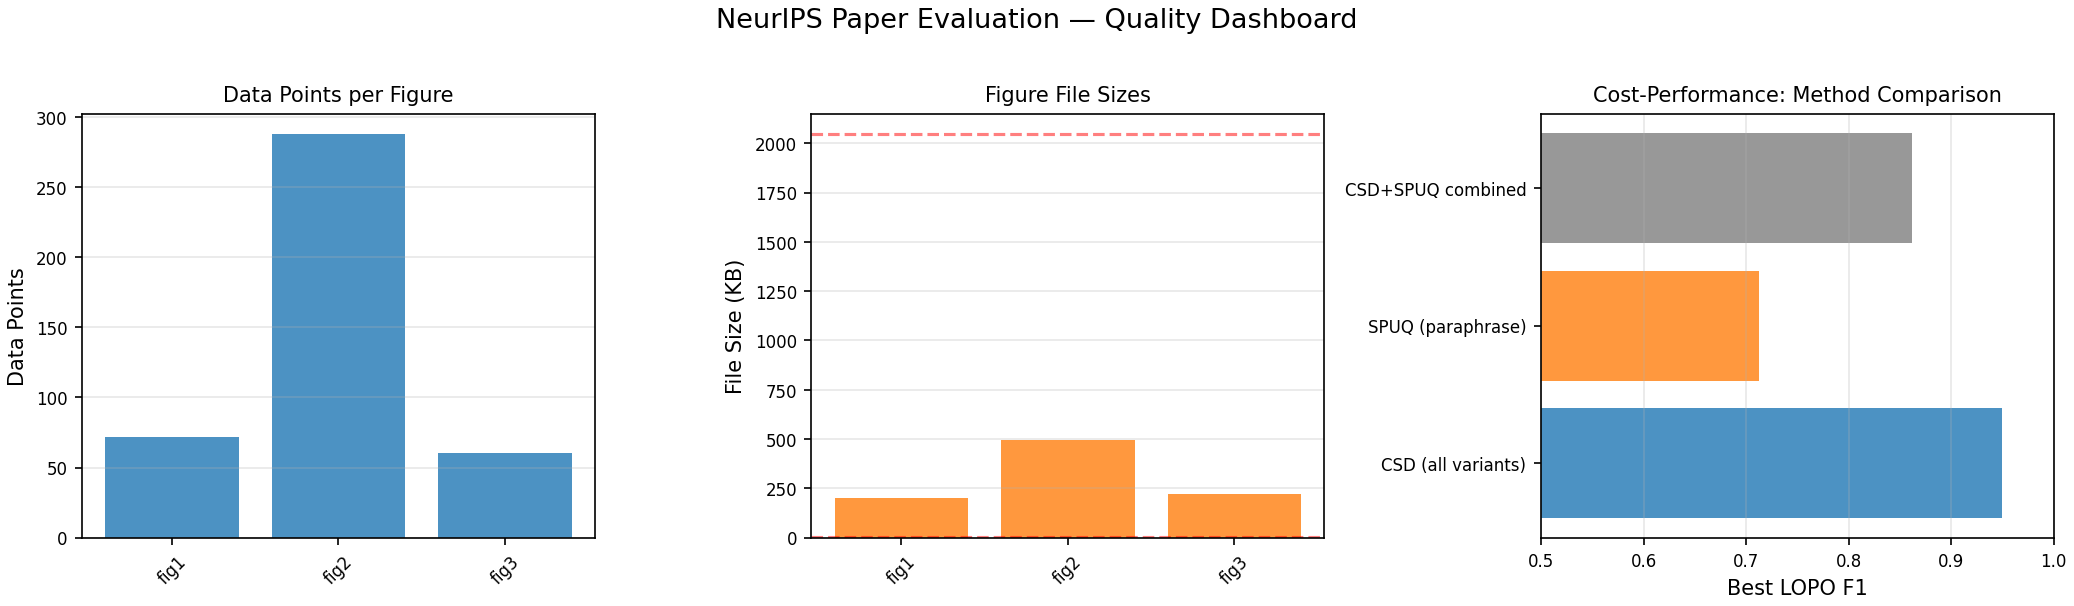

In [16]:
# ── Visualization: Evaluation Quality Dashboard ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Per-figure data points (from eval results)
fig_ds = [ds for ds in eval_results["datasets"] if ds["dataset"] == "figure_quality"][0]
fig_names = [ex["metadata_figure_name"] for ex in fig_ds["examples"]]
fig_points = [ex["eval_n_data_points"] for ex in fig_ds["examples"]]
fig_sizes = [ex["eval_filesize_png_kb"] for ex in fig_ds["examples"]]
axes[0].bar(fig_names, fig_points, color="#1f77b4", alpha=0.8)
axes[0].set_ylabel("Data Points")
axes[0].set_title("Data Points per Figure")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Figure file sizes
axes[1].bar(fig_names, fig_sizes, color="#ff7f0e", alpha=0.8)
axes[1].set_ylabel("File Size (KB)")
axes[1].set_title("Figure File Sizes")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(5, color="red", linestyle="--", alpha=0.5, label="Min (5 KB)")
axes[1].axhline(2048, color="red", linestyle="--", alpha=0.5, label="Max (2 MB)")
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Cost-performance bar chart
cost_ds = [ds for ds in eval_results["datasets"] if ds["dataset"] == "cost_comparison"][0]
methods = [ex["metadata_method"] for ex in cost_ds["examples"]]
f1_scores = [float(ex["predict_best_lopo_f1"]) for ex in cost_ds["examples"]]
bar_colors = ["#1f77b4" if "CSD" in m and "SPUQ" not in m else
              "#ff7f0e" if "SPUQ" in m and "CSD" not in m else "#7f7f7f"
              for m in methods]
axes[2].barh(methods, f1_scores, color=bar_colors, alpha=0.8)
axes[2].set_xlabel("Best LOPO F1")
axes[2].set_title("Cost-Performance: Method Comparison")
axes[2].set_xlim(0.5, 1.0)
axes[2].grid(True, alpha=0.3, axis="x")

fig.suptitle("NeurIPS Paper Evaluation — Quality Dashboard", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()